# Operazione di convoluzione

Si definisce la convoluzione su un'immagine $L \in \mathbb{R}^{H \times W}$ contro una maschera $M \in \mathbb{R}^{n \times n}$, dove $n < H$, $n < W$ e $n = 2m + 1$:

$$
(L * M)_{ij} = \sum_{a = -m}^m \sum_{b = -m}^m L_{i - a, j - b} M_{ab}
$$

NB: $L * M \in \mathbb{R}^{(H-n+1) \times (W - n+1)}$


Ad esempio, per $n = 3$:
$$
\begin{align*}
(L * M)_{ij} & = & L_{i - 1, j - 1} \cdot M_{1, 1} & + & L_{i - 1, j} \cdot M_{1, 0} & + & L_{i - 1, j + 1} \cdot M_{1, -1} + \\
& + & L_{i , j - 1} \cdot M_{0, 1} & + & L_{i , j} \cdot M_{0, 0} & + & L_{i , j + 1} \cdot M_{0, -1} +\\
& + & L_{i + 1, j - 1} \cdot M_{-1, 1} & + & L_{i + 1, j} \cdot M_{-1, 0} & + & L_{i + 1, j + 1} \cdot M_{-1, -1} 
\end{align*}
$$


In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
def apply_mask(img, mask):
    
    height = img.shape[0] - mask.shape[0] + 1

    width = img.shape[1] - mask.shape[1] + 1

    result = np.zeros((height, width))

    kernel_size = mask.shape[0]

    for i in range(height):
        for j in range(width):

            mat = img[ i:i + kernel_size, j:j + kernel_size ]

            result[i, j] = np.sum( np.multiply(mat, mask) )

    return result

### Filtro di Sobel e filtro Laplaciano

Definire il filtro di Sobel e il filtro Laplaciano.

In [6]:
img = mpimg.imread('img/3.jpg')

img_luminanza = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]

mask_x = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

mask_y = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

img_x = apply_mask(img_luminanza, mask_x)

img_y = apply_mask(img_luminanza, mask_y)

img_sobel = np.abs(img_x) + np.abs(img_y)

mask_laplace = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

img_laplace = apply_mask(img_luminanza, mask_laplace)


Caricare un'immagine e applicare i filtri di Sobel e Laplaciano su di essa.

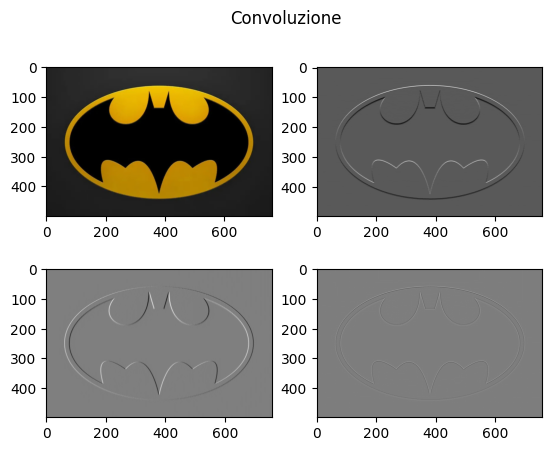

In [7]:
fig, axs = plt.subplots(2, 2)

fig.suptitle("Convoluzione")

axs[0, 0].imshow(img)

axs[0, 1].imshow(img_x, cmap='gray')

axs[1, 0].imshow(img_y, cmap='gray')

axs[1, 1].imshow(img_laplace, cmap='gray')

plt.show()

### Filtri di smoothing

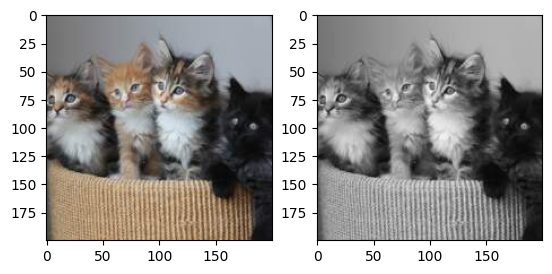

In [9]:
img = mpimg.imread('img/1.jpg')

img_luminanza = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]

fig, axs = plt.subplots(1, 2)

axs[0].imshow(img)
axs[1].imshow(img_luminanza, cmap='gray')

Definire un filtro di media $5 \times 5$. Applicarlo poi alla immagine precedente.

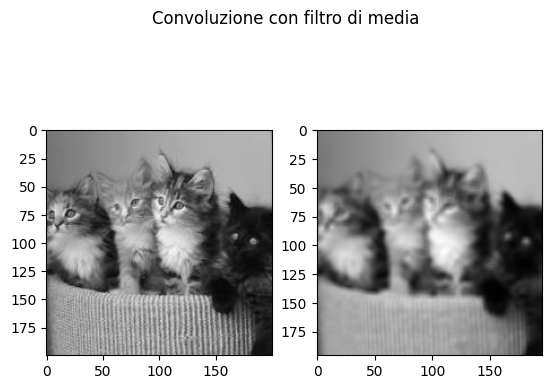

In [12]:
mask_media = np.array([
    [1/25, 1/25, 1/25, 1/25, 1/25],
    [1/25, 1/25, 1/25, 1/25, 1/25],
    [1/25, 1/25, 1/25, 1/25, 1/25],
    [1/25, 1/25, 1/25, 1/25, 1/25],
    [1/25, 1/25, 1/25, 1/25, 1/25]
])

img_media = apply_mask(img_luminanza, mask_media)
fig, axs = plt.subplots(1, 2)
fig.suptitle("Convoluzione con filtro di media")
axs[0].imshow(img_luminanza, cmap='gray')
axs[1].imshow(img_media, cmap='gray')

Definire un filtro Gaussiano $5 \times 5$. Applicarlo poi alla immagine precedente.

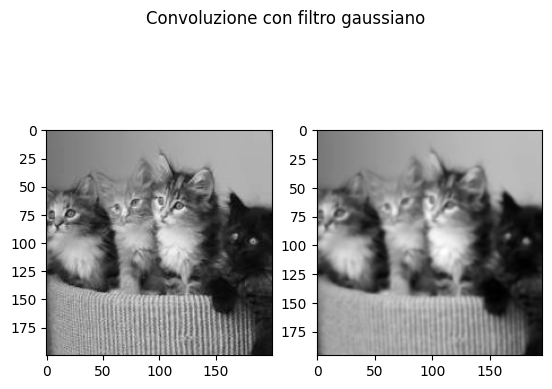

In [13]:
# filtro gaussiano
mask_gauss = np.zeros((5, 5))

cost_norm = 1 / (2 * np.pi)

def gauss(i, j):
    return cost_norm * np.exp( - (i**2 + j**2) / 2 )

for i in range(-2, 3):
    for j in range(-2, 3):
        mask_gauss[i + 2, j + 2] = gauss(i, j)

img_gauss = apply_mask(img_luminanza, mask_gauss)

fig, axs = plt.subplots(1, 2)
fig.suptitle("Convoluzione con filtro gaussiano")
axs[0].imshow(img_luminanza, cmap='gray')
axs[1].imshow(img_gauss, cmap='gray')

Definire i filtri di minimo e massimo, e il filtro mediano. In che cosa si differenziano rispetto ai filtri precedenti?

Text(0.5, 1.0, 'Mediano')

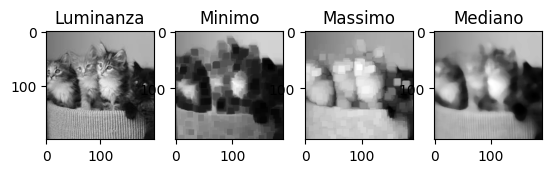

In [21]:
def minimum(img, i, j, n):
    return np.min(img[i:i + n, j:j + n])

def maximum(img, i, j, n):
    return np.max(img[i:i + n, j:j + n])

def median(img, i, j, n):
    return np.median(img[i:i + n, j:j + n])

N = 10

img_minimum = np.zeros((img_luminanza.shape[0] - N + 1, img_luminanza.shape[1] - N + 1))
img_maximum = np.zeros((img_luminanza.shape[0] - N + 1, img_luminanza.shape[1] - N + 1))
img_median = np.zeros((img_luminanza.shape[0] - N + 1, img_luminanza.shape[1] - N + 1))

for i in range(img_luminanza.shape[0] - N + 1):
    for j in range(img_luminanza.shape[1] - N + 1):
        img_minimum[i, j] = minimum(img_luminanza, i, j, N)
        img_maximum[i, j] = maximum(img_luminanza, i, j, N)
        img_median[i, j] = median(img_luminanza, i, j, N)

fig, axs = plt.subplots(1, 4)

axs[0].imshow(img_luminanza, cmap='gray')
axs[0].set_title("Luminanza")
axs[1].imshow(img_minimum, cmap='gray')
axs[1].set_title("Minimo")
axs[2].imshow(img_maximum, cmap='gray')
axs[2].set_title("Massimo")
axs[3].imshow(img_median, cmap='gray')
axs[3].set_title("Mediano")